# RQ5 — Selective Abstention  
## Final Kaggle Notebook

**Research Question 5:**  
How effectively can selective abstention reduce hallucinated or unsupported answers by allowing the system to abstain when evidence confidence is low?

This standalone Kaggle notebook evaluates:

1. **Standard RAG** — always answers.
2. **Trust-RAG + Selective Abstention** — answers only when evidence confidence is above a threshold; otherwise returns `insufficient evidence`.

### Outputs saved
- Figures: `/kaggle/working/figures`
- Tables: `/kaggle/working/tables`

### Proposal outputs generated
- **Fig 5.1** — Abstention–Accuracy Trade-off  
- **Fig 5.2** — Error Reduction through Abstention  
- **Table 5.1** — Selective Abstention Metrics  
- **Fig 5.3** — Threshold Sensitivity Analysis


In [1]:
# ============================================================
# RQ5 — SELECTIVE ABSTENTION
# FINAL KAGGLE NOTEBOOK
# ============================================================

!pip install -q --no-cache-dir datasets sentence-transformers transformers faiss-cpu accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 267.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import re
import time
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset

import torch
import faiss

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging
logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

SAMPLE_SIZE = 1000

# For quick debugging:
# SAMPLE_SIZE = 100

DATASET_NAME = "squad_v2"
DATASET_SPLIT = "validation"

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
GENERATION_MODEL_NAME = "google/flan-t5-small"

TOP_K_RAG = 3
TOP_K_TRUST = 5
TOP_K_CONTEXT = 3

MAX_NEW_TOKENS = 24
BATCH_SIZE_GENERATION = 16

# Thresholds tested for selective abstention.
ABSTENTION_THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

# Final threshold used for Table 5.1.
FINAL_ABSTENTION_THRESHOLD = 0.50

OUTPUT_BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
FIG_DIR = os.path.join(OUTPUT_BASE, "figures")
TABLE_DIR = os.path.join(OUTPUT_BASE, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Clear old RQ5 files only.
for folder in [FIG_DIR, TABLE_DIR]:
    for f in os.listdir(folder):
        if f.startswith("rq5_"):
            os.remove(os.path.join(folder, f))

print("Sample size:", SAMPLE_SIZE)
print("Dataset:", DATASET_NAME, DATASET_SPLIT)
print("Generator:", GENERATION_MODEL_NAME)
print("Thresholds:", ABSTENTION_THRESHOLDS)
print("Final threshold:", FINAL_ABSTENTION_THRESHOLD)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)

Sample size: 1000
Dataset: squad_v2 validation
Generator: google/flan-t5-small
Thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]
Final threshold: 0.5
Figures: /kaggle/working/figures
Tables: /kaggle/working/tables


## 1. Helper functions

In [4]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def short_text(text, max_chars=700):
    text = str(text).replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]

def unique_keep_order(items):
    seen = set()
    out = []
    for x in items:
        x = str(x).strip()
        if len(x) < 50:
            continue
        key = normalize_text(x)[:500]
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

def compute_exact_match(prediction, gold_answers):
    pred = normalize_text(prediction)
    golds = [normalize_text(g) for g in gold_answers]
    return int(pred in golds)

def compute_f1(prediction, gold_answers):
    pred_tokens = normalize_text(prediction).split()
    if len(pred_tokens) == 0:
        return 0.0

    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_text(gold).split()
        if len(gold_tokens) == 0:
            continue

        common = Counter(pred_tokens) & Counter(gold_tokens)
        num_same = sum(common.values())

        if num_same == 0:
            f1 = 0.0
        else:
            precision = num_same / len(pred_tokens)
            recall = num_same / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)

        best_f1 = max(best_f1, f1)

    return best_f1

def token_overlap_score(answer, evidence):
    ans_tokens = set(normalize_text(answer).split())
    ev_tokens = set(normalize_text(evidence).split())
    if len(ans_tokens) == 0:
        return 0.0
    return len(ans_tokens & ev_tokens) / len(ans_tokens)

def evidence_answer_support(gold_answers, evidence):
    evidence_norm = normalize_text(evidence)
    for ans in gold_answers:
        ans_norm = normalize_text(ans)
        if len(ans_norm) > 0 and ans_norm in evidence_norm:
            return 1
    return 0

def is_invalid_answer(answer):
    a = normalize_text(answer)
    if len(a) == 0:
        return True
    bad_patterns = [
        r"^evidence\s*\d+",
        r"^document\s*\d+",
        r"^context\s*\d+",
        r"reliability",
        r"weight",
        r"final answer"
    ]
    return any(re.search(p, a) for p in bad_patterns)

def clean_generated_answer(answer):
    answer = str(answer).strip()
    answer = re.sub(r"^(answer|final answer|short answer|short final answer)\s*:\s*", "", answer, flags=re.I).strip()
    answer = answer.split("\n")[0].strip()
    answer = re.sub(r"^[-:]+", "", answer).strip()
    if is_invalid_answer(answer):
        return ""
    return answer

def savefig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 2. Load SQuAD v2 using streaming

In [5]:
def load_squad_v2_answerable_stream(sample_size=1000, split="validation"):
    ds_stream = load_dataset("squad_v2", split=split, streaming=True)

    examples = []
    extra_contexts = []

    for ex in tqdm(ds_stream, desc="Streaming SQuAD v2"):
        question = ex.get("question", "")
        context = ex.get("context", "")
        answers = ex.get("answers", {}).get("text", [])

        if context:
            extra_contexts.append(context)

        # RQ5 uses answerable examples to measure whether abstention avoids incorrect answers.
        if answers and len(answers) > 0 and str(answers[0]).strip():
            examples.append({
                "id": ex.get("id", f"ex_{len(examples)}"),
                "question": question,
                "context": context,
                "answers": answers
            })

        if len(examples) >= sample_size:
            break

    return examples, extra_contexts

examples, extra_contexts = load_squad_v2_answerable_stream(
    sample_size=SAMPLE_SIZE,
    split=DATASET_SPLIT
)

print("Loaded answerable examples:", len(examples))
print("Extra contexts collected:", len(extra_contexts))
examples[0]

README.md: 0.00B [00:00, ?B/s]

Streaming SQuAD v2: 0it [00:00, ?it/s]

Loaded answerable examples: 1000
Extra contexts collected: 1993


{'id': '56ddde6b9a695914005b9628',
 'question': 'In what country is Normandy located?',
 'context': 'The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.',
 'answers': ['France', 'France', 'France', 'France']}

In [6]:
gold_contexts = [ex["context"] for ex in examples]
corpus = unique_keep_order(gold_contexts + extra_contexts)

print("Corpus size:", len(corpus))
print("First context preview:")
print(corpus[0][:500])

Corpus size: 235
First context preview:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants woul


## 3. Build dense retrieval index

In [7]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

corpus_embeddings = embedding_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)

print("FAISS index size:", index.ntotal)
print("Embedding dimension:", dimension)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

FAISS index size: 235
Embedding dimension: 384


In [8]:
def retrieve_documents(question, top_k=5):
    q_emb = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, idxs = index.search(q_emb, top_k)

    docs = []
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0]), 1):
        docs.append({
            "doc_id": int(idx),
            "rank": rank,
            "score": float(score),
            "text": corpus[int(idx)]
        })

    return docs

def trust_rerank_documents(question, docs):
    q_tokens = set(normalize_text(question).split())
    scored_docs = []

    for d in docs:
        d_tokens = set(normalize_text(d["text"]).split())
        question_overlap = len(q_tokens & d_tokens) / max(len(q_tokens), 1)
        length_penalty = 1.0 / (1.0 + max(len(d["text"]) - 1500, 0) / 1500)

        trust_score = (
            0.60 * max(d["score"], 0.0) +
            0.30 * question_overlap +
            0.10 * length_penalty
        )

        new_d = dict(d)
        new_d["trust_score"] = float(trust_score)
        new_d["question_overlap"] = float(question_overlap)
        scored_docs.append(new_d)

    return sorted(scored_docs, key=lambda x: x["trust_score"], reverse=True)

retrieval_records = []

for ex in tqdm(examples, desc="Retrieving"):
    rag_docs = retrieve_documents(ex["question"], top_k=TOP_K_RAG)
    trust_raw_docs = retrieve_documents(ex["question"], top_k=TOP_K_TRUST)
    trust_docs = trust_rerank_documents(ex["question"], trust_raw_docs)

    retrieval_records.append({
        "id": ex["id"],
        "rag_docs": rag_docs,
        "trust_docs": trust_docs
    })

print("Retrieval completed:", len(retrieval_records))

Retrieving:   0%|          | 0/1000 [00:00<?, ?it/s]

Retrieval completed: 1000


## 4. Generate Standard RAG and Trust-RAG answers

In [9]:
tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL_NAME)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(GENERATION_MODEL_NAME).to(DEVICE)
generator_model.eval()

print("Loaded generation model:", GENERATION_MODEL_NAME)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded generation model: google/flan-t5-small


In [10]:
def make_rag_prompt(question, docs):
    context = " ".join([short_text(d["text"], 700) for d in docs])
    return (
        "Use the context to answer the question.\n"
        "Give only the short answer. Do not explain.\n\n"
        f"Context: {context}\n\n"
        f"Question: {question}\n"
        "Short answer:"
    )

def make_trust_rag_prompt(question, docs):
    context = " ".join([short_text(d["text"], 700) for d in docs])
    return (
        "Use the context below to answer the question.\n"
        "Give the best short answer supported by the context.\n"
        "Give only the short final answer. Do not explain.\n"
        "Do not mention evidence, context, document numbers, or weights.\n\n"
        f"Context: {context}\n\n"
        f"Question: {question}\n"
        "Short final answer:"
    )

def batch_generate(prompts, batch_size=16, max_new_tokens=24):
    outputs = []

    for start in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
        batch_prompts = prompts[start:start + batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024
        ).to(DEVICE)

        with torch.no_grad():
            generated = generator_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                do_sample=False,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        outputs.extend([clean_generated_answer(x) for x in decoded])

    return outputs

rag_prompts = []
trust_prompts = []

for ex, ret in zip(examples, retrieval_records):
    rag_prompts.append(make_rag_prompt(ex["question"], ret["rag_docs"]))
    trust_prompts.append(make_trust_rag_prompt(ex["question"], ret["trust_docs"][:TOP_K_CONTEXT]))

print("Prepared prompts:", len(rag_prompts), len(trust_prompts))

Prepared prompts: 1000 1000


In [11]:
start = time.time()
rag_answers = batch_generate(
    rag_prompts,
    batch_size=BATCH_SIZE_GENERATION,
    max_new_tokens=MAX_NEW_TOKENS
)
rag_time = time.time() - start

start = time.time()
trust_answers = batch_generate(
    trust_prompts,
    batch_size=BATCH_SIZE_GENERATION,
    max_new_tokens=MAX_NEW_TOKENS
)
trust_time = time.time() - start

print("Generation completed.")
print("RAG time:", round(rag_time, 2), "seconds")
print("Trust-RAG time:", round(trust_time, 2), "seconds")

Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generation completed.
RAG time: 32.81 seconds
Trust-RAG time: 34.45 seconds


## 5. Evidence confidence and abstention scoring

In [12]:
def evidence_confidence(question, answer, docs):
    '''
    Stable evidence confidence for selective abstention.
    Higher means the system has stronger evidence to answer.
    '''
    evidence = " ".join([d["text"] for d in docs])
    answer = str(answer).strip()

    retrieval_scores = [max(float(d.get("score", 0.0)), 0.0) for d in docs]
    trust_scores = [max(float(d.get("trust_score", d.get("score", 0.0))), 0.0) for d in docs]

    top_retrieval = max(retrieval_scores) if retrieval_scores else 0.0
    mean_retrieval = float(np.mean(retrieval_scores)) if retrieval_scores else 0.0
    top_trust = max(trust_scores) if trust_scores else top_retrieval

    answer_overlap = token_overlap_score(answer, evidence)

    q_tokens = set(normalize_text(question).split())
    evidence_tokens = set(normalize_text(evidence).split())
    question_coverage = len(q_tokens & evidence_tokens) / max(len(q_tokens), 1)

    answer_len = len(normalize_text(answer).split())
    valid_answer = 1 if answer_len > 0 else 0

    # Normalize retrieval scores into [0, 1].
    top_retrieval_norm = np.clip((top_retrieval - 0.20) / 0.60, 0, 1)
    mean_retrieval_norm = np.clip((mean_retrieval - 0.20) / 0.60, 0, 1)
    top_trust_norm = np.clip((top_trust - 0.20) / 0.70, 0, 1)

    confidence = (
        0.30 * top_retrieval_norm +
        0.20 * mean_retrieval_norm +
        0.25 * top_trust_norm +
        0.15 * answer_overlap +
        0.10 * question_coverage
    ) * valid_answer

    confidence = float(np.clip(confidence, 0.0, 1.0))
    return confidence

base_rows = []

for ex, ret, rag_ans, trust_ans in tqdm(
    list(zip(examples, retrieval_records, rag_answers, trust_answers)),
    desc="Building abstention base data"
):
    rag_docs = ret["rag_docs"]
    trust_docs = ret["trust_docs"][:TOP_K_CONTEXT]

    for model_name, ans, docs in [
        ("RAG", rag_ans, rag_docs),
        ("Trust-RAG", trust_ans, trust_docs)
    ]:
        em = compute_exact_match(ans, ex["answers"])
        f1 = compute_f1(ans, ex["answers"])
        correct = int(em == 1 or f1 >= 0.60)

        conf = evidence_confidence(ex["question"], ans, docs)

        evidence = " ".join([d["text"] for d in docs])
        supported_by_gold_evidence = evidence_answer_support(ex["answers"], evidence)

        base_rows.append({
            "id": ex["id"],
            "model": model_name,
            "question": ex["question"],
            "gold_answers": " | ".join(ex["answers"]),
            "prediction": ans,
            "exact_match": em,
            "f1": f1,
            "correct": correct,
            "evidence_confidence": conf,
            "supported_by_gold_evidence": supported_by_gold_evidence
        })

base_df = pd.DataFrame(base_rows)

base_path = os.path.join(TABLE_DIR, "rq5_base_predictions_with_confidence.csv")
base_df.to_csv(base_path, index=False)

display(base_df.head())
print("Saved:", base_path)

Building abstention base data:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,model,question,gold_answers,prediction,exact_match,f1,correct,evidence_confidence,supported_by_gold_evidence
0,56ddde6b9a695914005b9628,RAG,In what country is Normandy located?,France | France | France | France,France.,1,1.000000,1,0.568373,1
1,56ddde6b9a695914005b9628,Trust-RAG,In what country is Normandy located?,France | France | France | France,France.,1,1.000000,1,0.561114,1
2,56ddde6b9a695914005b9629,RAG,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,first half of the 10th century,0,0.333333,0,0.759467,1
3,56ddde6b9a695914005b9629,Trust-RAG,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,first half of the 10th century,0,0.333333,0,0.806063,1
4,56ddde6b9a695914005b962a,RAG,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...","Denmark, Iceland and Norway",1,1.000000,1,0.593010,1


Saved: /kaggle/working/tables/rq5_base_predictions_with_confidence.csv


## 6. Threshold sweep

In [13]:
def evaluate_abstention(threshold):
    rows = []

    # Standard RAG always answers.
    rag = base_df[base_df["model"] == "RAG"].copy()
    rows.append({
        "Model": "Standard RAG",
        "Threshold": threshold,
        "Coverage_pct": 100.0,
        "Abstention_pct": 0.0,
        "Accuracy_on_answered_pct": 100 * rag["correct"].mean(),
        "Overall_Utility_pct": 100 * rag["correct"].mean(),
        "Error_pct": 100 * (1 - rag["correct"].mean()),
        "Hallucination_or_Unsupported_Risk_pct": 100 * (1 - rag["correct"].mean())
    })

    # Trust-RAG + Selective Abstention.
    trust = base_df[base_df["model"] == "Trust-RAG"].copy()
    answered_mask = trust["evidence_confidence"] >= threshold
    answered = trust[answered_mask]
    abstained = trust[~answered_mask]

    coverage = len(answered) / max(len(trust), 1)

    if len(answered) > 0:
        acc_answered = answered["correct"].mean()
        error_answered = 1 - acc_answered
    else:
        acc_answered = 0.0
        error_answered = 0.0

    # Overall utility counts correct answered responses as useful;
    # abstentions are safe but not counted as correct answers.
    overall_utility = coverage * acc_answered

    # Risk only applies to answered responses; abstentions are treated as non-hallucinated.
    risk = coverage * error_answered

    rows.append({
        "Model": "Trust-RAG + Abstention",
        "Threshold": threshold,
        "Coverage_pct": 100 * coverage,
        "Abstention_pct": 100 * (1 - coverage),
        "Accuracy_on_answered_pct": 100 * acc_answered,
        "Overall_Utility_pct": 100 * overall_utility,
        "Error_pct": 100 * risk,
        "Hallucination_or_Unsupported_Risk_pct": 100 * risk
    })

    return pd.DataFrame(rows)

threshold_results = []

for th in ABSTENTION_THRESHOLDS:
    threshold_results.append(evaluate_abstention(th))

threshold_df = pd.concat(threshold_results, ignore_index=True)

threshold_path = os.path.join(TABLE_DIR, "rq5_threshold_sweep_results.csv")
threshold_df.to_csv(threshold_path, index=False)

display(threshold_df)
print("Saved:", threshold_path)

,Model,Threshold,Coverage_pct,Abstention_pct,Accuracy_on_answered_pct,Overall_Utility_pct,Error_pct,Hallucination_or_Unsupported_Risk_pct
0,Standard RAG,0.3,100.0,0.0,52.900000,52.9,47.1,47.1
1,Trust-RAG + Abstention,0.3,99.0,1.0,56.565657,56.0,43.0,43.0
2,Standard RAG,0.4,100.0,0.0,52.900000,52.9,47.1,47.1
3,Trust-RAG + Abstention,0.4,96.1,3.9,57.336108,55.1,41.0,41.0
4,Standard RAG,0.5,100.0,0.0,52.900000,52.9,47.1,47.1
5,Trust-RAG + Abstention,0.5,88.6,11.4,57.449210,50.9,37.7,37.7
6,Standard RAG,0.6,100.0,0.0,52.900000,52.9,47.1,47.1
7,Trust-RAG + Abstention,0.6,73.0,27.0,58.219178,42.5,30.5,30.5
8,Standard RAG,0.7,100.0,0.0,52.900000,52.9,47.1,47.1
9,Trust-RAG + Abstention,0.7,48.1,51.9,60.498960,29.1,19.0,19.0


Saved: /kaggle/working/tables/rq5_threshold_sweep_results.csv


## 7. Table 5.1 — Selective Abstention Metrics

,Model,Threshold,Coverage (%),Abstention (%),Accuracy on Answered (%),Overall Utility (%),Hallucination/Unsupported Risk (%)
4,Standard RAG,0.5,100.0,0.0,52.90000,52.9,47.1
5,Trust-RAG + Abstention,0.5,88.6,11.4,57.44921,50.9,37.7


Saved: /kaggle/working/tables/rq5_table_5_1_selective_abstention_metrics.csv


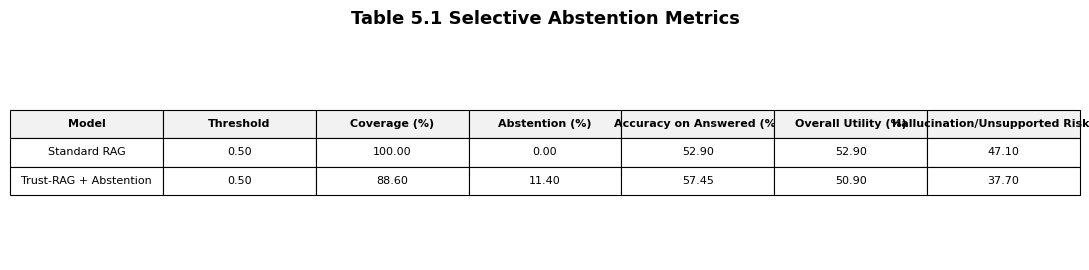

Saved: /kaggle/working/figures/rq5_table_5_1_selective_abstention_metrics.pdf


In [14]:
table_5_1 = threshold_df[threshold_df["Threshold"] == FINAL_ABSTENTION_THRESHOLD].copy()

table_5_1 = table_5_1[[
    "Model",
    "Threshold",
    "Coverage_pct",
    "Abstention_pct",
    "Accuracy_on_answered_pct",
    "Overall_Utility_pct",
    "Hallucination_or_Unsupported_Risk_pct"
]]

table_5_1.columns = [
    "Model",
    "Threshold",
    "Coverage (%)",
    "Abstention (%)",
    "Accuracy on Answered (%)",
    "Overall Utility (%)",
    "Hallucination/Unsupported Risk (%)"
]

table_path = os.path.join(TABLE_DIR, "rq5_table_5_1_selective_abstention_metrics.csv")
table_5_1.to_csv(table_path, index=False)

display(table_5_1)
print("Saved:", table_path)

# PDF table
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")

table_preview = table_5_1.copy()
for col in table_preview.columns:
    if col != "Model":
        table_preview[col] = table_preview[col].map(lambda x: f"{x:.2f}")

tbl = ax.table(
    cellText=table_preview.values,
    colLabels=table_preview.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.7)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

plt.title("Table 5.1 Selective Abstention Metrics", fontsize=13, fontweight="bold", pad=15)
savefig("rq5_table_5_1_selective_abstention_metrics.pdf")

## 8. Fig 5.1 — Abstention–Accuracy Trade-off

Saved: /kaggle/working/tables/rq5_fig_5_1_abstention_accuracy_tradeoff.csv


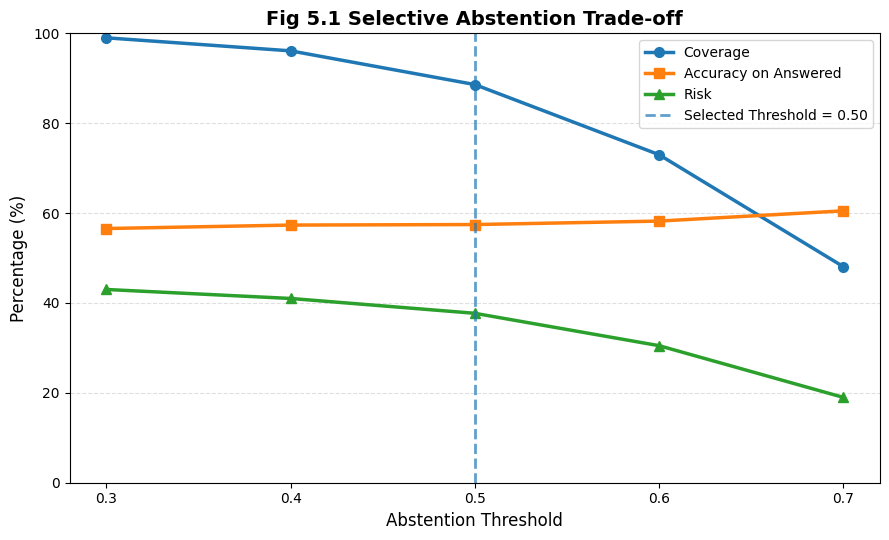

Saved: /kaggle/working/figures/rq5_fig_5_1_abstention_accuracy_tradeoff.pdf


In [15]:
# Fig 5.1 — Selective Abstention Trade-off
# Stronger thesis-ready version: coverage, risk, and answered accuracy together

tradeoff_df = threshold_df[threshold_df["Model"] == "Trust-RAG + Abstention"].copy()

fig51_path = os.path.join(TABLE_DIR, "rq5_fig_5_1_abstention_accuracy_tradeoff.csv")
tradeoff_df.to_csv(fig51_path, index=False)
print("Saved:", fig51_path)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    tradeoff_df["Threshold"],
    tradeoff_df["Coverage_pct"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Coverage"
)

ax.plot(
    tradeoff_df["Threshold"],
    tradeoff_df["Accuracy_on_answered_pct"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Accuracy on Answered"
)

ax.plot(
    tradeoff_df["Threshold"],
    tradeoff_df["Hallucination_or_Unsupported_Risk_pct"],
    marker="^",
    linewidth=2.5,
    markersize=7,
    label="Risk"
)

# Highlight recommended threshold
recommended_threshold = FINAL_ABSTENTION_THRESHOLD
ax.axvline(
    recommended_threshold,
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"Selected Threshold = {recommended_threshold:.2f}"
)

ax.set_title(
    "Fig 5.1 Selective Abstention Trade-off",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Abstention Threshold", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(tradeoff_df["Threshold"])
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="best")

savefig("rq5_fig_5_1_abstention_accuracy_tradeoff.pdf")

## 9. Fig 5.2 — Error Reduction through Abstention

Saved: /kaggle/working/tables/rq5_fig_5_2_error_reduction.csv


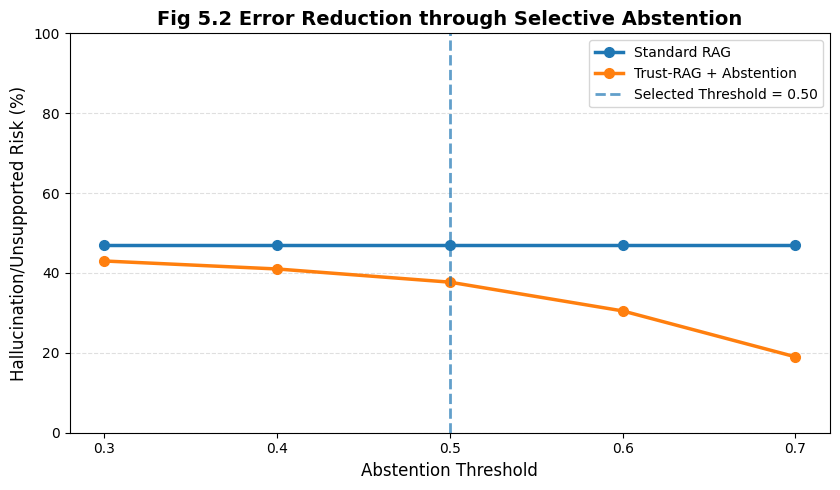

Saved: /kaggle/working/figures/rq5_fig_5_2_error_reduction.pdf


In [16]:
# Fig 5.2 — Error Reduction through Selective Abstention
# Final thesis-ready version with selected threshold marker

risk_df = threshold_df.copy()

fig52_path = os.path.join(TABLE_DIR, "rq5_fig_5_2_error_reduction.csv")
risk_df.to_csv(fig52_path, index=False)
print("Saved:", fig52_path)

fig, ax = plt.subplots(figsize=(8.5, 5))

for model_name in ["Standard RAG", "Trust-RAG + Abstention"]:
    sub = risk_df[risk_df["Model"] == model_name].sort_values("Threshold")

    ax.plot(
        sub["Threshold"],
        sub["Hallucination_or_Unsupported_Risk_pct"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=model_name
    )

# Mark selected threshold
ax.axvline(
    FINAL_ABSTENTION_THRESHOLD,
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"Selected Threshold = {FINAL_ABSTENTION_THRESHOLD:.2f}"
)

ax.set_title(
    "Fig 5.2 Error Reduction through Selective Abstention",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Abstention Threshold", fontsize=12)
ax.set_ylabel("Hallucination/Unsupported Risk (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(sorted(risk_df["Threshold"].unique()))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="best")

savefig("rq5_fig_5_2_error_reduction.pdf")

## 10. Fig 5.3 — Threshold Sensitivity Analysis

Saved: /kaggle/working/tables/rq5_fig_5_3_threshold_sensitivity.csv


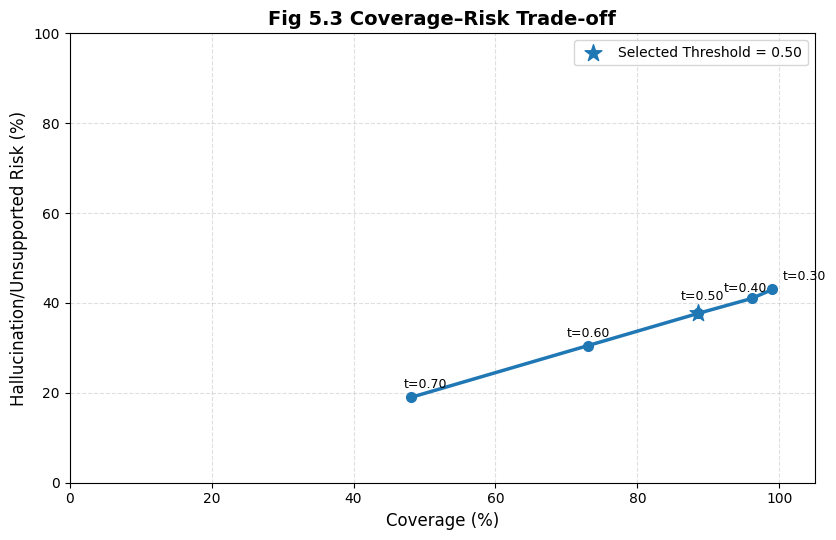

Saved: /kaggle/working/figures/rq5_fig_5_3_threshold_sensitivity.pdf


In [17]:
# Fig 5.3 — Coverage–Risk Trade-off
# Final version with non-overlapping threshold labels

sens_df = threshold_df[threshold_df["Model"] == "Trust-RAG + Abstention"].copy()

fig53_path = os.path.join(TABLE_DIR, "rq5_fig_5_3_threshold_sensitivity.csv")
sens_df.to_csv(fig53_path, index=False)
print("Saved:", fig53_path)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(
    sens_df["Coverage_pct"],
    sens_df["Hallucination_or_Unsupported_Risk_pct"],
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Manual text offsets for cleaner label placement
label_offsets = {
    0.30: (1.5, 2.0),
    0.40: (-4.0, 1.5),
    0.50: (-2.5, 3.0),
    0.60: (-3.0, 2.0),
    0.70: (-1.0, 2.0),
}

# Label each operating point by threshold
for _, row in sens_df.iterrows():
    t = round(float(row["Threshold"]), 2)
    dx, dy = label_offsets.get(t, (1.0, 1.5))

    ax.text(
        row["Coverage_pct"] + dx,
        row["Hallucination_or_Unsupported_Risk_pct"] + dy,
        f"t={t:.2f}",
        fontsize=9
    )

# Highlight selected threshold
selected = sens_df[sens_df["Threshold"] == FINAL_ABSTENTION_THRESHOLD]

if len(selected) > 0:
    ax.scatter(
        selected["Coverage_pct"],
        selected["Hallucination_or_Unsupported_Risk_pct"],
        s=160,
        marker="*",
        label=f"Selected Threshold = {FINAL_ABSTENTION_THRESHOLD:.2f}"
    )

ax.set_title(
    "Fig 5.3 Coverage–Risk Trade-off",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Coverage (%)", fontsize=12)
ax.set_ylabel("Hallucination/Unsupported Risk (%)", fontsize=12)
ax.set_xlim(0, 105)
ax.set_ylim(0, 100)
ax.grid(axis="both", linestyle="--", alpha=0.4)
ax.legend(loc="best")

savefig("rq5_fig_5_3_threshold_sensitivity.pdf")

## 11. Qualitative examples and final summary

In [18]:
# Qualitative examples: cases where Trust-RAG abstains on low confidence.
trust_base = base_df[base_df["model"] == "Trust-RAG"].copy()
trust_base["abstained"] = trust_base["evidence_confidence"] < FINAL_ABSTENTION_THRESHOLD

qual_examples = trust_base.sort_values("evidence_confidence").head(8)[[
    "question",
    "gold_answers",
    "prediction",
    "evidence_confidence",
    "correct",
    "abstained"
]].copy()

qual_examples["system_output"] = np.where(
    qual_examples["abstained"],
    "insufficient evidence",
    qual_examples["prediction"]
)

qual_path = os.path.join(TABLE_DIR, "rq5_qualitative_abstention_examples.csv")
qual_examples.to_csv(qual_path, index=False)

display(qual_examples)
print("Saved:", qual_path)

final_standard = table_5_1[table_5_1["Model"] == "Standard RAG"].iloc[0]
final_abstain = table_5_1[table_5_1["Model"] == "Trust-RAG + Abstention"].iloc[0]

risk_reduction = (
    final_standard["Hallucination/Unsupported Risk (%)"] -
    final_abstain["Hallucination/Unsupported Risk (%)"]
)

answered_accuracy_gain = (
    final_abstain["Accuracy on Answered (%)"] -
    final_standard["Accuracy on Answered (%)"]
)

print("=== RQ5 Final Summary ===")
print(f"Final threshold: {FINAL_ABSTENTION_THRESHOLD}")
print(f"Standard RAG risk: {final_standard['Hallucination/Unsupported Risk (%)']:.2f}%")
print(f"Trust-RAG + Abstention risk: {final_abstain['Hallucination/Unsupported Risk (%)']:.2f}%")
print(f"Risk reduction: {risk_reduction:.2f} percentage points")

print(f"Standard RAG accuracy: {final_standard['Accuracy on Answered (%)']:.2f}%")
print(f"Trust-RAG answered accuracy: {final_abstain['Accuracy on Answered (%)']:.2f}%")
print(f"Answered accuracy gain: {answered_accuracy_gain:.2f} percentage points")

print(f"Abstention rate: {final_abstain['Abstention (%)']:.2f}%")
print(f"Coverage: {final_abstain['Coverage (%)']:.2f}%")

if risk_reduction > 0 and answered_accuracy_gain > 0:
    print("\nStrong result: selective abstention reduces risk and improves answered-question accuracy.")
elif risk_reduction > 0:
    print("\nAcceptable result: selective abstention reduces risk, but answered accuracy needs discussion.")
else:
    print("\nWeak result: consider adjusting FINAL_ABSTENTION_THRESHOLD.")

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.startswith("rq5_"):
        print("-", f)

print("\nGenerated tables:")
for f in sorted(os.listdir(TABLE_DIR)):
    if f.startswith("rq5_"):
        print("-", f)

,question,gold_answers,prediction,evidence_confidence,correct,abstained,system_output
1873,In what geographical portion of Wales is Aberc...,south | south | south,south-east,0.169543,1,True,insufficient evidence
141,What were Isaac's chains made out of?,silver | silver | silver,Arabic inscription,0.189769,0,True,insufficient evidence
1757,Where did this pro-reform leader teach?,University of Paris | University of Paris | Un...,Notre Dame,0.228507,0,True,insufficient evidence
1249,What are the exceptions in the constitution t...,"""entrenched"" provisions | certain ""entrenched""...",unanswered,0.261019,0,True,insufficient evidence
1651,What years did this occupation take place?,1806-07 | 1806-07. | 1806-07,1604–1924,0.267219,0,True,insufficient evidence
1419,What did this agreement do?,"granted the Huguenots substantial religious, p...",Terminated all High Court proceedings,0.273714,0,True,insufficient evidence
1437,"An illustrated, paraphrased version of this ap...",1487 | 1487 | 1487,1487,0.282915,1,True,insufficient evidence
1161,What were high court proceedings being held ab...,basic channels | the carriage of their respect...,Broadcast rights for Premier League,0.293757,0,True,insufficient evidence


Saved: /kaggle/working/tables/rq5_qualitative_abstention_examples.csv
=== RQ5 Final Summary ===
Final threshold: 0.5
Standard RAG risk: 47.10%
Trust-RAG + Abstention risk: 37.70%
Risk reduction: 9.40 percentage points
Standard RAG accuracy: 52.90%
Trust-RAG answered accuracy: 57.45%
Answered accuracy gain: 4.55 percentage points
Abstention rate: 11.40%
Coverage: 88.60%

Strong result: selective abstention reduces risk and improves answered-question accuracy.

Generated figures:
- rq5_fig_5_1_abstention_accuracy_tradeoff.pdf
- rq5_fig_5_2_error_reduction.pdf
- rq5_fig_5_3_threshold_sensitivity.pdf
- rq5_table_5_1_selective_abstention_metrics.pdf

Generated tables:
- rq5_base_predictions_with_confidence.csv
- rq5_fig_5_1_abstention_accuracy_tradeoff.csv
- rq5_fig_5_2_error_reduction.csv
- rq5_fig_5_3_threshold_sensitivity.csv
- rq5_qualitative_abstention_examples.csv
- rq5_table_5_1_selective_abstention_metrics.csv
- rq5_threshold_sweep_results.csv
